In [2]:
import pandas as pd 
import numpy as np

import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df =pd.read_excel("D:\data science\project\home loans project\Home+Loans+Dataset.xlsx")
df.head(5)

,Customer Number,Applied Loan Amount in Lacs,Month,Fin Year,Month Year,Channel Id,Product Id,Gender,Occupation,Age,Salary,Branch Code
0,1,6,1,2018,1-2018,2,2,Female,Salaried,56-63,25+,14
1,2,16,1,2019,1-2019,4,3,Male,Salaried,33-43,9 LPA - 15 LPA,5
2,3,2,4,2019,4-2019,1,2,Third Gender,Salaried,26-32,3 LPA - 5 LPA,1
3,4,8,7,2019,7-2019,3,2,Third Gender,Salaried,26-32,15 LPA - 25 LPA,7
4,5,24,9,2019,9-2019,3,4,Male,Salaried,33-43,15 LPA - 25 LPA,15


In [13]:
# reading the sheet name 
dff=pd.ExcelFile("D:\data science\project\home loans project\Home+Loans+Dataset.xlsx")
print(dff.sheet_names)

['Customer', 'Sanction Data', 'Recovery Data', 'Branch', 'Channel', 'Product']


In [3]:
customer = pd.read_excel(r"D:\data science\project\home loans project\Home+Loans+Dataset.xlsx", sheet_name="Customer")
Sanction_Data = pd.read_excel(r"D:\data science\project\home loans project\Home+Loans+Dataset.xlsx", sheet_name="Sanction Data")
Branch = pd.read_excel(r"D:\data science\project\home loans project\Home+Loans+Dataset.xlsx", sheet_name="Branch")
Channel = pd.read_excel(r"D:\data science\project\home loans project\Home+Loans+Dataset.xlsx", sheet_name="Channel")
Recovery_Data = pd.read_excel(r"D:\data science\project\home loans project\Home+Loans+Dataset.xlsx", sheet_name="Recovery Data")
Product = pd.read_excel(r"D:\data science\project\home loans project\Home+Loans+Dataset.xlsx", sheet_name="Product")

In [18]:
customer


,Customer Number,Applied Loan Amount in Lacs,Month,Fin Year,Month Year,Channel Id,Product Id,Gender,Occupation,Age,Salary,Branch Code
0,1,6,1,2018,1-2018,2,2,Female,Salaried,56-63,25+,14
1,2,16,1,2019,1-2019,4,3,Male,Salaried,33-43,9 LPA - 15 LPA,5
2,3,2,4,2019,4-2019,1,2,Third Gender,Salaried,26-32,3 LPA - 5 LPA,1
3,4,8,7,2019,7-2019,3,2,Third Gender,Salaried,26-32,15 LPA - 25 LPA,7
4,5,24,9,2019,9-2019,3,4,Male,Salaried,33-43,15 LPA - 25 LPA,15
...,...,...,...,...,...,...,...,...,...,...,...,...
25231,25232,2,6,2017,6-2017,4,1,Male,Salaried,63+,5 LPA - 7 LPA,8
25232,25233,14,1,2019,1-2019,3,1,Female,Salaried,26-32,15 LPA - 25 LPA,9
25233,25234,24,8,2018,8-2018,3,2,Female,Business,26-32,7 LPA - 9 LPA,8
25234,25235,8,3,2017,3-2017,2,2,Third Gender,Business,44-55,15 LPA - 25 LPA,11


In [18]:
customer.columns

Index(['Customer Number', 'Applied Loan Amount in Lacs', 'Month', 'Fin Year',
       'Month Year', 'Channel Id', 'Product Id', 'Gender', 'Occupation', 'Age',
       'Salary', 'Branch Code'],
      dtype='str')

## Q1:- What is the distribution of customers by gender, occupation, age group, and salary bracket?

In [14]:
#total customer of each category 
total_customer = customer['Customer Number'].count()
print('total customer =',total_customer)

print(customer['Gender'].value_counts())
print (customer['Age'].value_counts())
print(customer['Occupation'].value_counts())
print(customer['Age'].value_counts())
print(customer['Salary'].value_counts())

total customer = 25236
Gender
Male            8489
Female          8382
Third Gender    8365
Name: count, dtype: int64
Age
26-32    8482
44-55    4270
63+      4202
56-63    4160
33-43    4122
Name: count, dtype: int64
Occupation
Salaried    14228
Business    11008
Name: count, dtype: int64
Age
26-32    8482
44-55    4270
63+      4202
56-63    4160
33-43    4122
Name: count, dtype: int64
Salary
25+                4274
15 LPA - 25 LPA    4255
3 LPA - 5 LPA      4201
9 LPA - 15 LPA     4199
5 LPA - 7 LPA      4192
7 LPA - 9 LPA      4115
Name: count, dtype: int64


## Q2:- What is the average applied loan amount for each occupation?

In [28]:
customer.groupby('Occupation')['Applied Loan Amount in Lacs'].mean()

Occupation
Business    9.750363
Salaried    9.692367
Name: Applied Loan Amount in Lacs, dtype: float64

## Q3:-	What is the distribution of the applied loan amounts

In [13]:
customer['Applied Loan Amount in Lacs'].describe()
customer['Applied Loan Amount in Lacs'].value_counts().sort_index()


Applied Loan Amount in Lacs
1     1134
2     2160
3      984
4     2146
5     1068
6     2055
7     1100
8     2069
9     1058
10    1948
11    1059
12    2143
14     992
16    1084
18    1088
20    1087
22    1032
24    1029
Name: count, dtype: int64

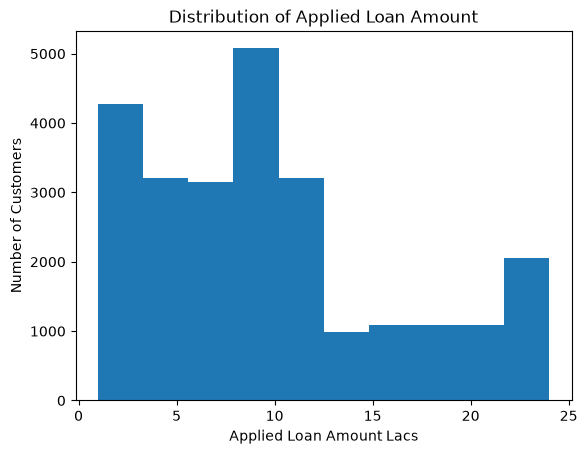

In [26]:
customer["Applied Loan Amount in Lacs"].plot(
    kind="hist",
    bins=10
)

plt.xlabel("Applied Loan Amount Lacs")
plt.ylabel("Number of Customers")
plt.title("Distribution of Applied Loan Amount")
plt.show()

## Q4:- Which channel is the most popular for loan applications?

In [21]:
channel_count = customer['Channel Id'].value_counts().reset_index()

channel_count.columns = ['Channel Id', 'Application Count']

channel_count = channel_count.merge(
    Channel[['Channel Id', 'Channels']],
    on='Channel Id',
    how='left'
)

print(channel_count)

   Channel Id  Application Count            Channels
0           3               8489              Online
1           1               6267  Direct Sales Aency
2           2               6261             Walk-In
3           4               4219             Tie Ups


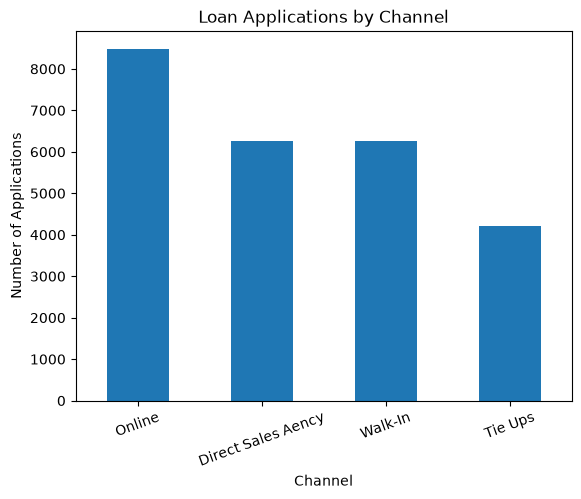

In [25]:


# merge Customer and Channel sheets
data = customer.merge(Channel, on='Channel Id', how='left')

# Count applications by channel
data['Channels'].value_counts().plot(kind='bar')

plt.title('Loan Applications by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Applications')
plt.xticks(rotation=20)
plt.show()

## Q5:-	What is the overall sanction rate (percentage of sanctioned applications out of total applications)?

In [11]:
total_applications = customer['Customer Number'].nunique()
sanctioned_applications = Sanction_Data['Customer Number'].nunique()

sanction_rate = sanctioned_applications / total_applications * 100

print("Sanction Rate =", round(sanction_rate, 2), "%")

Sanction Rate = 100.0 %


## Q6:-What is the average difference between the applied loan amount and the sanctioned amount?

In [15]:
Sanction_Data['Difference'] = (
    Sanction_Data['Applied Loan Amount in Lacs']
    - Sanction_Data['Sanction Amt in Lacs']
)

average_difference = Sanction_Data['Difference'].mean()

print("Average Difference =", round(average_difference, 2), "Lacs")

Average Difference = 1.29 Lacs


In [5]:
average_difference = (
    Sanction_Data['Applied Loan Amount in Lacs']
    - Sanction_Data['Sanction Amt in Lacs']
).mean()

print(round(average_difference,2),'lacs')

1.29 lacs


In [16]:
Sanction_Data

,Customer Number,Applied Loan Amount in Lacs,Month,Fin Year,Month Year,Sanction Amt in Lacs,Disb Amt in Lacs,SDF Branch,Difference
0,1,6,1,2018,1-2018,4.8,4.416,Gandhinagar,1.2
1,2,16,1,2019,1-2019,12.8,11.776,Bengaluru,3.2
2,3,2,4,2019,4-2019,1.9,1.748,Mumbai,0.1
3,4,8,7,2019,7-2019,7.6,6.992,Chennai,0.4
4,5,24,9,2019,9-2019,19.2,17.664,Ranchi,4.8
...,...,...,...,...,...,...,...,...,...
25231,25232,2,6,2017,6-2017,1.6,1.472,Jaipur,0.4
25232,25233,14,1,2019,1-2019,13.3,12.236,Aurangabad,0.7
25233,25234,24,8,2018,8-2018,22.8,20.976,Jaipur,1.2
25234,25235,8,3,2017,3-2017,6.4,5.888,Chandigarh,1.6


## Q7 what is the total recovery amount of each branch?

In [7]:
Recovery_Data.groupby('Recovery Branch')['Recovery Amount'].sum()

Recovery Branch
Aurangabad     7135.2992
Bengaluru      6508.0064
Bhopal         6872.1792
Chandigarh     6947.0304
Chennai        7375.6768
Delhi          7110.4224
Gandhinagar    6899.8528
Jaipur         6762.4416
Mumbai         7070.8992
Nagpur         7169.8912
Nasik          7327.3952
Pune           6626.5760
Ranchi         6277.1968
Shillong       7062.8032
Srinagar       7050.4384
Name: Recovery Amount, dtype: float64

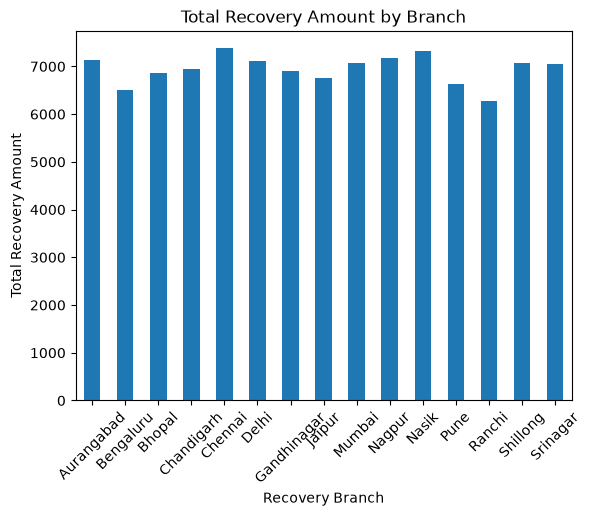

In [9]:
Recovery_Data.groupby('Recovery Branch')['Recovery Amount'].sum().plot(kind='bar')

plt.title('Total Recovery Amount by Branch')
plt.xlabel('Recovery Branch')
plt.ylabel('Total Recovery Amount')
plt.xticks(rotation=45)
plt.show()

## Q8 Which branch has the highest number of loan applications?

In [11]:
data = customer.merge(
    Branch[['Branch Code', 'Branch Name']],
    on='Branch Code',
    how='left'
)

branch_applications = data['Branch Name'].value_counts()

print(branch_applications)

Branch Name
Mumbai         1764
Bengaluru      1733
Delhi          1718
Gandhinagar    1711
Jaipur         1711
Nasik          1704
Shillong       1678
Bhopal         1676
Ranchi         1672
Nagpur         1666
Pune           1656
Chennai        1650
Chandigarh     1637
Aurangabad     1632
Srinagar       1628
Name: count, dtype: int64


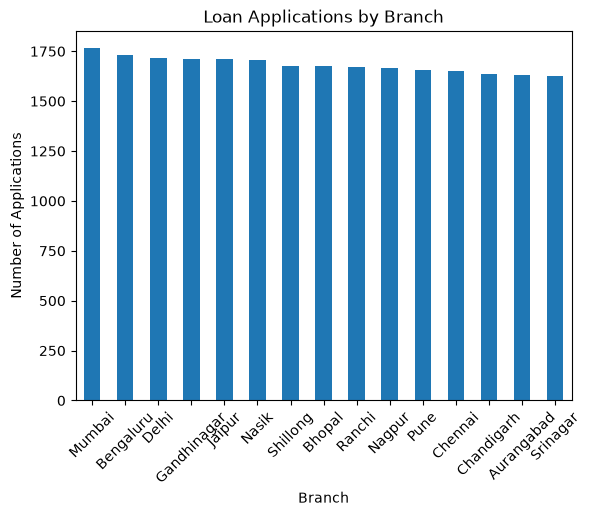

In [12]:
branch_applications.plot(kind='bar')

plt.title('Loan Applications by Branch')
plt.xlabel('Branch')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)
plt.show()

## Q9 what is the performance of each channel in terms of the number of applications, sanction amount, and recovery amounts?

In [16]:
data = customer.merge(
    Channel[['Channel Id', 'Channels']],
    on='Channel Id',
    how='left'
)
sanction_total = Sanction_Data.groupby(
    'Customer Number'
)['Sanction Amt in Lacs'].sum().reset_index()
recovery_total = Recovery_Data.groupby(
    'Customer Number'
)['Recovery Amount'].sum().reset_index()
data = data.merge(sanction_total, on='Customer Number', how='left')

data = data.merge(recovery_total, on='Customer Number', how='left')

data[['Sanction Amt in Lacs', 'Recovery Amount']] = \
    data[['Sanction Amt in Lacs', 'Recovery Amount']].fillna(0)


In [17]:
channel_performance = data.groupby('Channels').agg(
    Applications=('Customer Number', 'nunique'),
    Sanction_Amount=('Sanction Amt in Lacs', 'sum'),
    Recovery_Amount=('Recovery Amount', 'sum')
).reset_index()

print(channel_performance)

             Channels  Applications  Sanction_Amount  Recovery_Amount
0  Direct Sales Aency          6267          53031.0       26091.9360
1              Online          8489          79767.9       34746.1184
2             Tie Ups          4219          27113.6       17372.9856
3             Walk-In          6261          52818.7       25985.0688


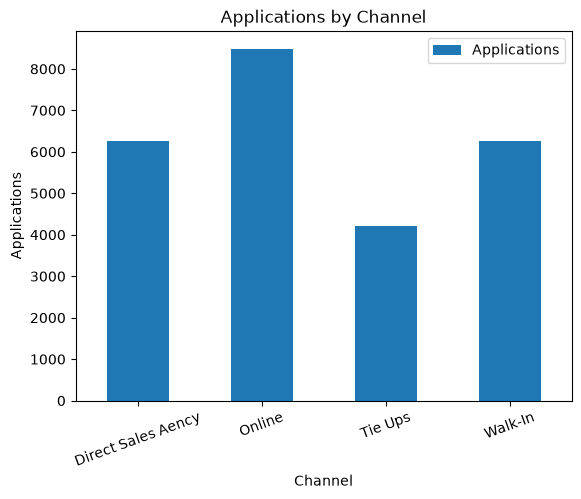

In [18]:
channel_performance.plot(
    x='Channels',
    y='Applications',
    kind='bar'
)

plt.title('Applications by Channel')
plt.xlabel('Channel')
plt.ylabel('Applications')
plt.xticks(rotation=20)
plt.show()

## Q 10 Which product has the highest total sanctioned loan amount?

In [20]:
data = customer.merge(
    Product[['Product Id', 'Products']],
    on='Product Id',
    how='left'
)

data = data.merge(
    Sanction_Data[['Customer Number', 'Sanction Amt in Lacs']],
    on='Customer Number',
    how='left'
)

In [21]:
product_sanction = data.groupby(
    'Products'
)['Sanction Amt in Lacs'].sum()

print(product_sanction)

Products
Loans                           52405.0
Loans + Group Insurance         54131.0
Loans + Individual Insurance    53001.3
Loans + Top-up                  53193.9
Name: Sanction Amt in Lacs, dtype: float64


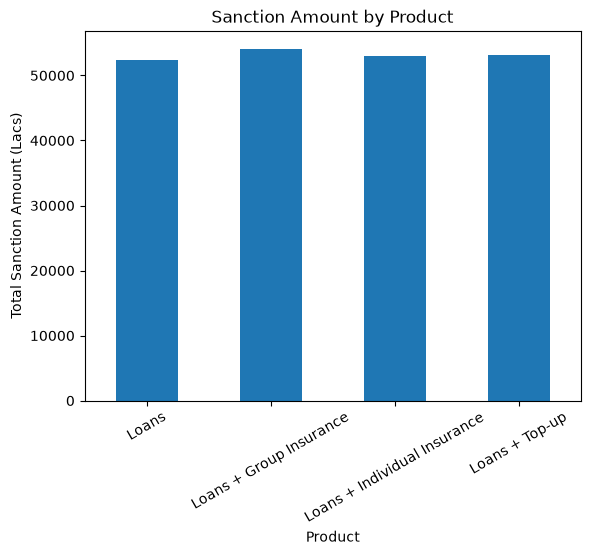

In [22]:
product_sanction.plot(kind='bar')

plt.title('Sanction Amount by Product')
plt.xlabel('Product')
plt.ylabel('Total Sanction Amount (Lacs)')
plt.xticks(rotation=30)
plt.show()